In [25]:
# --- loads our saved trained models and the data ---

%run ./r_model_data_loader.ipynb

Test shape: (685159, 191)
Weeks: 44 - 91 (48 unieke weken)
Default rate: 0.0335 (22955 positieven)
LR : C=0.000195172, l1_ratio=0.0, n_features=191
XGB: n_trees=450, n_features=191
MLP: hidden=[128], n_features=191
Device: cpu


c:\Users\Vik\Documents\UGent\Masterproef\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Results - Explainable Stability

## 3.3.0 Setup

De drie bevroren modellen worden uitgelegd met `shap.PermutationExplainer` op de log-odds
schaal, zodat de SHAP-waarden van LR, XGB en MLP in dezelfde eenheid staan. Dat gebeurt op
de raw featureruimte: de preprocessing (winsorisatie, imputatie, frequency encoding,
z-scoring) zit niet in een pipeline maar is in m2 al in de parquet verwerkt, dus de drie
modellen delen exact dezelfde kolommen en zijn de featurenamen zonder meer vergelijkbaar.

In [26]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import shap
from scipy import stats
from sklearn.linear_model import LogisticRegression

# --- SHAP config ---

TOP_K = 20
N_BACKGROUND = 100
N_BASELINE = 500
N_PER_WEEK = 250
SEED = 42
TRAIN_WEEKS = range(0, 44)
TEST_WEEKS = range(44, 92)
COVID_WEEK = 62
MAX_EVALS = 383  # 2 * 191 features + 1

RESULTS_DIR = "shap_results"
CACHE_PATH = f"{RESULTS_DIR}/shap_cache.parquet"

BASELINE_WEEK = -1
MODELS = ["LR", "XGB", "MLP"]
COLORS = {"LR": "dimgray", "XGB": "crimson", "MLP": "darkorange"}

BLOCKS = {
    "volledig": [w for w in TEST_WEEKS],
    "pre-COVID": [w for w in TEST_WEEKS if w < COVID_WEEK],
    "post-COVID": [w for w in TEST_WEEKS if w >= COVID_WEEK],
}

os.makedirs(RESULTS_DIR, exist_ok=True)

models = {"LR": lr_best, "XGB": xgb_best, "MLP": mlp_best}

feature_names = list(X_test.columns)
n_features = len(feature_names)
if MAX_EVALS < 2 * n_features + 1:
    raise ValueError(f"MAX_EVALS={MAX_EVALS} ligt onder het minimum van "
                     f"2 * {n_features} + 1 = {2 * n_features + 1}")

print(f"Features: {n_features}")
print(f"MAX_EVALS: {MAX_EVALS} (minimum 2 * {n_features} + 1 = {2 * n_features + 1})")

Features: 191
MAX_EVALS: 383 (minimum 2 * 191 + 1 = 383)


In [27]:
# --- background and baseline data ---
# Eén trekking uit het volledige trainingsblok, daarna gesplitst in een achtergrondset (waartegen
# gemaskeerd wordt) en een baselineset (de rijen die uitgelegd worden). Beide zijn identiek voor
# de drie modellen; de baseline krijgt week = -1 in de cache.

train_df = pd.read_parquet(f"{DATA_DIR}/df_train_preprocessed_cutoff44.parquet")
train_df = train_df[train_df["WEEK_NUM"].isin(TRAIN_WEEKS)]

rng = np.random.default_rng(SEED)
draw = rng.choice(len(train_df), N_BACKGROUND + N_BASELINE, replace=False)
train_sample = train_df.iloc[np.sort(draw)].drop(columns=id_cols + ["target"])

background = train_sample.iloc[:N_BACKGROUND]
X_baseline = train_sample.iloc[N_BACKGROUND:]

del train_df

# max_samples moet expliciet: zonder dat argument dunt shap de background stil uit tot 100.
masker = shap.maskers.Independent(background, max_samples=N_BACKGROUND)

print(f"Background: {len(background)} rijen, baseline: {len(X_baseline)} rijen")
print(f"Zelfde kolommen als X_test: {list(background.columns) == list(X_test.columns)}")

Background: 100 rijen, baseline: 500 rijen
Zelfde kolommen als X_test: True


In [28]:
# De weektrekkingen worden vooraf gemaakt, zodat de drie modellen gegarandeerd op dezelfde
# rijen worden uitgelegd. week_num_test staat in dezelfde rijvolgorde als X_test (zie loader).
week_num = week_num_test.to_numpy()

week_samples = {}
for week in TEST_WEEKS:
    week_rows = np.flatnonzero(week_num == week)
    week_rng = np.random.default_rng([SEED, week])
    week_draw = week_rng.choice(week_rows, min(N_PER_WEEK, len(week_rows)), replace=False)
    week_samples[week] = X_test.iloc[np.sort(week_draw)]

print(f"Testweken: {min(week_samples)}-{max(week_samples)} ({len(week_samples)} weken), "
      f"{N_PER_WEEK} rijen per week")

Testweken: 44-91 (48 weken), 250 rijen per week


In [29]:
def predict_logodds(model, X):
    """Score op de log-odds schaal, zodat de SHAP-waarden van de drie modellen in
    dezelfde eenheid staan."""
    if isinstance(model, LogisticRegression):
        return model.decision_function(X)

    if isinstance(model, XGBClassifier):
        return model.predict(np.asarray(X, dtype=np.float32), output_margin=True)

    # De MLP is een TorchScript-module met één output, getraind met BCEWithLogitsLoss:
    # die output IS de logit. Sigmoid nemen en daar weer de logit van berekenen zou exact
    # dezelfde waarde opnieuw opbouwen en enkel precisie kosten. Het clippen houden we wel
    # aan, zodat de schaal eindig blijft.
    with torch.no_grad():
        logits = model(torch.tensor(np.asarray(X, dtype=np.float32), device=device))
    return np.clip(logits.cpu().numpy().ravel(), -30.0, 30.0)

In [30]:
def load_done_pairs():
    if not os.path.exists(CACHE_PATH):
        return set()
    cache = pd.read_parquet(CACHE_PATH, columns=["model", "week"])
    return set(zip(cache["model"], cache["week"]))


def append_to_cache(rows):
    if os.path.exists(CACHE_PATH):
        rows = pd.concat([pd.read_parquet(CACHE_PATH), rows], ignore_index=True)

    # Eerst volledig naar een tijdelijk bestand schrijven en dan pas vervangen: een crash
    # tijdens het schrijven laat de bestaande cache dan onbeschadigd achter.
    tmp_path = CACHE_PATH + ".tmp"
    rows.to_parquet(tmp_path, index=False)
    os.replace(tmp_path, CACHE_PATH)

In [31]:
# --- SHAP calculation ---

done = load_done_pairs()
if done:
    print(f"Cache bevat al {len(done)} (model, week) paren")

for model_name, model in models.items():

    def model_fn(X, model=model):
        return predict_logodds(model, X)

    explainer = shap.PermutationExplainer(model_fn, masker, seed=SEED)

    jobs = [(BASELINE_WEEK, X_baseline)]
    for week in TEST_WEEKS:
        jobs.append((week, week_samples[week]))

    for week, X_week in jobs:
        if (model_name, week) in done:
            print(f"{model_name:>3}  week {week:>3}  overgeslagen (al in cache)")
            continue

        start = time.perf_counter()

        # batch_size expliciet: de standaard "auto" kiest hier veel te kleine batches en
        # maakt de run ongeveer een factor drie trager.
        explanation = explainer(X_week, max_evals=MAX_EVALS, batch_size=50_000, silent=True)
        mean_abs_shap = np.abs(explanation.values).mean(axis=0)

        rows = pd.DataFrame({
            "model": model_name,
            "week": week,
            "feature": list(X_week.columns),
            "mean_abs_shap": mean_abs_shap,
        })
        append_to_cache(rows)

        print(f"{model_name:>3}  week {week:>3}  {time.perf_counter() - start:.1f}s")

print(f"Klaar. Cache: {CACHE_PATH}")

Cache bevat al 147 (model, week) paren
 LR  week  -1  overgeslagen (al in cache)
 LR  week  44  overgeslagen (al in cache)
 LR  week  45  overgeslagen (al in cache)
 LR  week  46  overgeslagen (al in cache)
 LR  week  47  overgeslagen (al in cache)
 LR  week  48  overgeslagen (al in cache)
 LR  week  49  overgeslagen (al in cache)
 LR  week  50  overgeslagen (al in cache)
 LR  week  51  overgeslagen (al in cache)
 LR  week  52  overgeslagen (al in cache)
 LR  week  53  overgeslagen (al in cache)
 LR  week  54  overgeslagen (al in cache)
 LR  week  55  overgeslagen (al in cache)
 LR  week  56  overgeslagen (al in cache)
 LR  week  57  overgeslagen (al in cache)
 LR  week  58  overgeslagen (al in cache)
 LR  week  59  overgeslagen (al in cache)
 LR  week  60  overgeslagen (al in cache)
 LR  week  61  overgeslagen (al in cache)
 LR  week  62  overgeslagen (al in cache)
 LR  week  63  overgeslagen (al in cache)
 LR  week  64  overgeslagen (al in cache)
 LR  week  65  overgeslagen (al in ca

## 3.3.1 Verklarende stabiliteit

Per model wordt de baselineband bevroren: de top-25 features van de baselinerijen (week = -1),
gesorteerd op mean |SHAP|. Die band verschilt per model, en dat is de bedoeling - elk model
wordt tegen zijn eigen uitgangspunt gelegd.

Vier metrieken op die band:

- **Spearman** - de TOP_K baselinefeatures onderling gerangschikt in de baseline tegenover
  diezelfde features onderling gerangschikt in week t. Meet enkel de volgorde.
- **Pearson** - dezelfde vergelijking maar op de mean |SHAP| zelf in plaats van op de rangen,
  dus ook gevoelig voor de grootte van de bijdragen. Blijft de volgorde gelijk terwijl één
  feature veel zwaarder gaat wegen, dan zakt Pearson terwijl Spearman hoog blijft.
- **Overlap** - de eigen top-25 van week t over ALLE features, doorsneden met de baselineband,
  gedeeld door TOP_K.
- **CoV** - per feature in de band de std (ddof=1) gedeeld door het gemiddelde over de weken
  van een blok, daarna gemiddeld over de TOP_K features. Eén waarde per blok.

In [32]:
# Deze cel staat bewust voor de beeswarms: die markeren de features die buiten de
# baselineband vallen en hebben `bands` dus al nodig. Verder komen `tables`, `cov_per_feature`,
# `weekly` en `summary` hier vandaan, die de rest van de sectie gebruikt.
cache = pd.read_parquet(CACHE_PATH)

weekly_rows = []
summary_rows = []
cov_per_feature = {}
bands = {}
tables = {}

for model_name in MODELS:
    model_cache = cache[cache["model"] == model_name]
    table = model_cache.pivot(index="week", columns="feature", values="mean_abs_shap")
    tables[model_name] = table

    baseline = table.loc[BASELINE_WEEK]
    band = baseline.sort_values(ascending=False).index[:TOP_K].tolist()
    bands[model_name] = band

    baseline_ranks = stats.rankdata(baseline[band])

    model_weekly = []
    for week in TEST_WEEKS:
        week_values = table.loc[week]

        # Beide rangvectoren lopen over dezelfde TOP_K features, elk gerangschikt binnen
        # die groep: de baselinevolgorde tegenover de volgorde in week t.
        week_ranks = stats.rankdata(week_values[band])
        spearman = stats.spearmanr(baseline_ranks, week_ranks).statistic
        pearson = stats.pearsonr(baseline[band], week_values[band]).statistic

        week_top = week_values.sort_values(ascending=False).index[:TOP_K]
        overlap = len(set(week_top) & set(band)) / TOP_K

        model_weekly.append({"model": model_name, "week": week, "spearman": spearman,
                             "pearson": pearson, "overlap": overlap})

    model_weekly = pd.DataFrame(model_weekly)
    weekly_rows.append(model_weekly)

    for block_name, block_weeks in BLOCKS.items():
        block_table = table.loc[block_weeks, band]
        feature_cov = block_table.std(ddof=1) / block_table.mean()
        cov_per_feature[(model_name, block_name)] = feature_cov.to_numpy()

        block_weekly = model_weekly[model_weekly["week"].isin(block_weeks)]
        summary_rows.append({
            "model": model_name,
            "block": block_name,
            "spearman_mean": block_weekly["spearman"].mean(),
            "spearman_std": block_weekly["spearman"].std(ddof=1),
            "pearson_mean": block_weekly["pearson"].mean(),
            "pearson_std": block_weekly["pearson"].std(ddof=1),
            "cov_mean": feature_cov.mean(),
            "overlap_mean": block_weekly["overlap"].mean(),
            "overlap_std": block_weekly["overlap"].std(ddof=1),
        })

weekly = pd.concat(weekly_rows, ignore_index=True)
summary = pd.DataFrame(summary_rows)

weekly.to_csv(f"{RESULTS_DIR}/shap_weekly.csv", index=False)
summary.to_csv(f"{RESULTS_DIR}/shap_summary.csv", index=False)

print(f"Baselineband per model (top-{TOP_K} features, eerste vijf)")
for model_name in MODELS:
    print(f"  {model_name:>3}: {', '.join(bands[model_name][:5])}")
print()
summary.round(4)

Baselineband per model (top-20 features, eerste vijf)
   LR: days120_123L, monthsannuity_845L, mobilephncnt_593L, datelastunpaid_3546854D_missing, max_numberofoverdueinstlmaxdat_641D_missing
  XGB: pmtnum_254L, max_dpdmax_139P, mobilephncnt_593L, max_dpdmaxdateyear_596T, max_empl_employedfrom_271D
  MLP: mobilephncnt_593L, days120_123L, pmtnum_254L, pmtscount_423L, annuity_780A



,model,block,spearman_mean,spearman_std,pearson_mean,pearson_std,cov_mean,overlap_mean,overlap_std
0,LR,volledig,0.5957,0.0287,0.4945,0.0352,0.0483,0.7406,0.0522
1,LR,pre-COVID,0.5936,0.0389,0.4698,0.0430,0.0452,0.7833,0.0594
2,LR,post-COVID,0.5969,0.0211,0.5094,0.0179,0.0350,0.7150,0.0233
3,XGB,volledig,0.6863,0.0262,0.6118,0.0247,0.0646,0.8094,0.0197
4,XGB,pre-COVID,0.7098,0.0192,0.6033,0.0264,0.0497,0.8083,0.0192
5,XGB,post-COVID,0.6722,0.0186,0.6169,0.0225,0.0497,0.8100,0.0203
6,MLP,volledig,0.5977,0.0327,0.6002,0.0265,0.0662,0.6719,0.0573
7,MLP,pre-COVID,0.6217,0.0289,0.6025,0.0285,0.0557,0.6500,0.0594
8,MLP,post-COVID,0.5833,0.0260,0.5987,0.0256,0.0554,0.6850,0.0528


### Baseline

In [33]:
PRE_MID_WEEK = BLOCKS["pre-COVID"][len(BLOCKS["pre-COVID"]) // 2]
POST_MID_WEEK = BLOCKS["post-COVID"][len(BLOCKS["post-COVID"]) // 2]

FOCUS_WEEKS = {
    BASELINE_WEEK: "baseline (trainingsblok)",
    PRE_MID_WEEK: f"week {PRE_MID_WEEK} (midden pre-COVID)",
    POST_MID_WEEK: f"week {POST_MID_WEEK} (midden post-COVID)",
}
BEESWARM_CACHE = f"{RESULTS_DIR}/shap_beeswarm.npz"

focus_samples = {BASELINE_WEEK: X_baseline}
for week in [PRE_MID_WEEK, POST_MID_WEEK]:
    focus_samples[week] = week_samples[week]


def load_beeswarm_cache():
    if not os.path.exists(BEESWARM_CACHE):
        return {}
    with np.load(BEESWARM_CACHE) as stored:
        return {key: stored[key] for key in stored.files}


def save_beeswarm_cache(arrays):
    tmp_path = BEESWARM_CACHE + ".tmp.npz"
    np.savez_compressed(tmp_path, **arrays)
    os.replace(tmp_path, BEESWARM_CACHE)


arrays = load_beeswarm_cache()

for model_name, model in models.items():

    def model_fn(X, model=model):
        return predict_logodds(model, X)

    explainer = shap.PermutationExplainer(model_fn, masker, seed=SEED)

    for week, X_focus in focus_samples.items():
        key = f"values_{model_name}_{week}"
        if key in arrays:
            print(f"{model_name:>3}  week {week:>3}  overgeslagen (al in cache)")
            continue

        start = time.perf_counter()
        explanation = explainer(X_focus, max_evals=MAX_EVALS, batch_size=50_000, silent=True)

        # De featurewaarden zijn identiek voor de drie modellen, dus die staan per week
        # maar een keer in de cache.
        arrays[key] = explanation.values
        arrays[f"data_{week}"] = X_focus.to_numpy(dtype=np.float64)
        save_beeswarm_cache(arrays)

        print(f"{model_name:>3}  week {week:>3}  {time.perf_counter() - start:.1f}s")

print(f"Klaar. Cache: {BEESWARM_CACHE}")

 LR  week  -1  overgeslagen (al in cache)
 LR  week  53  overgeslagen (al in cache)
 LR  week  77  overgeslagen (al in cache)
XGB  week  -1  overgeslagen (al in cache)
XGB  week  53  overgeslagen (al in cache)
XGB  week  77  overgeslagen (al in cache)
MLP  week  -1  overgeslagen (al in cache)
MLP  week  53  overgeslagen (al in cache)
MLP  week  77  overgeslagen (al in cache)
Klaar. Cache: shap_results/shap_beeswarm.npz


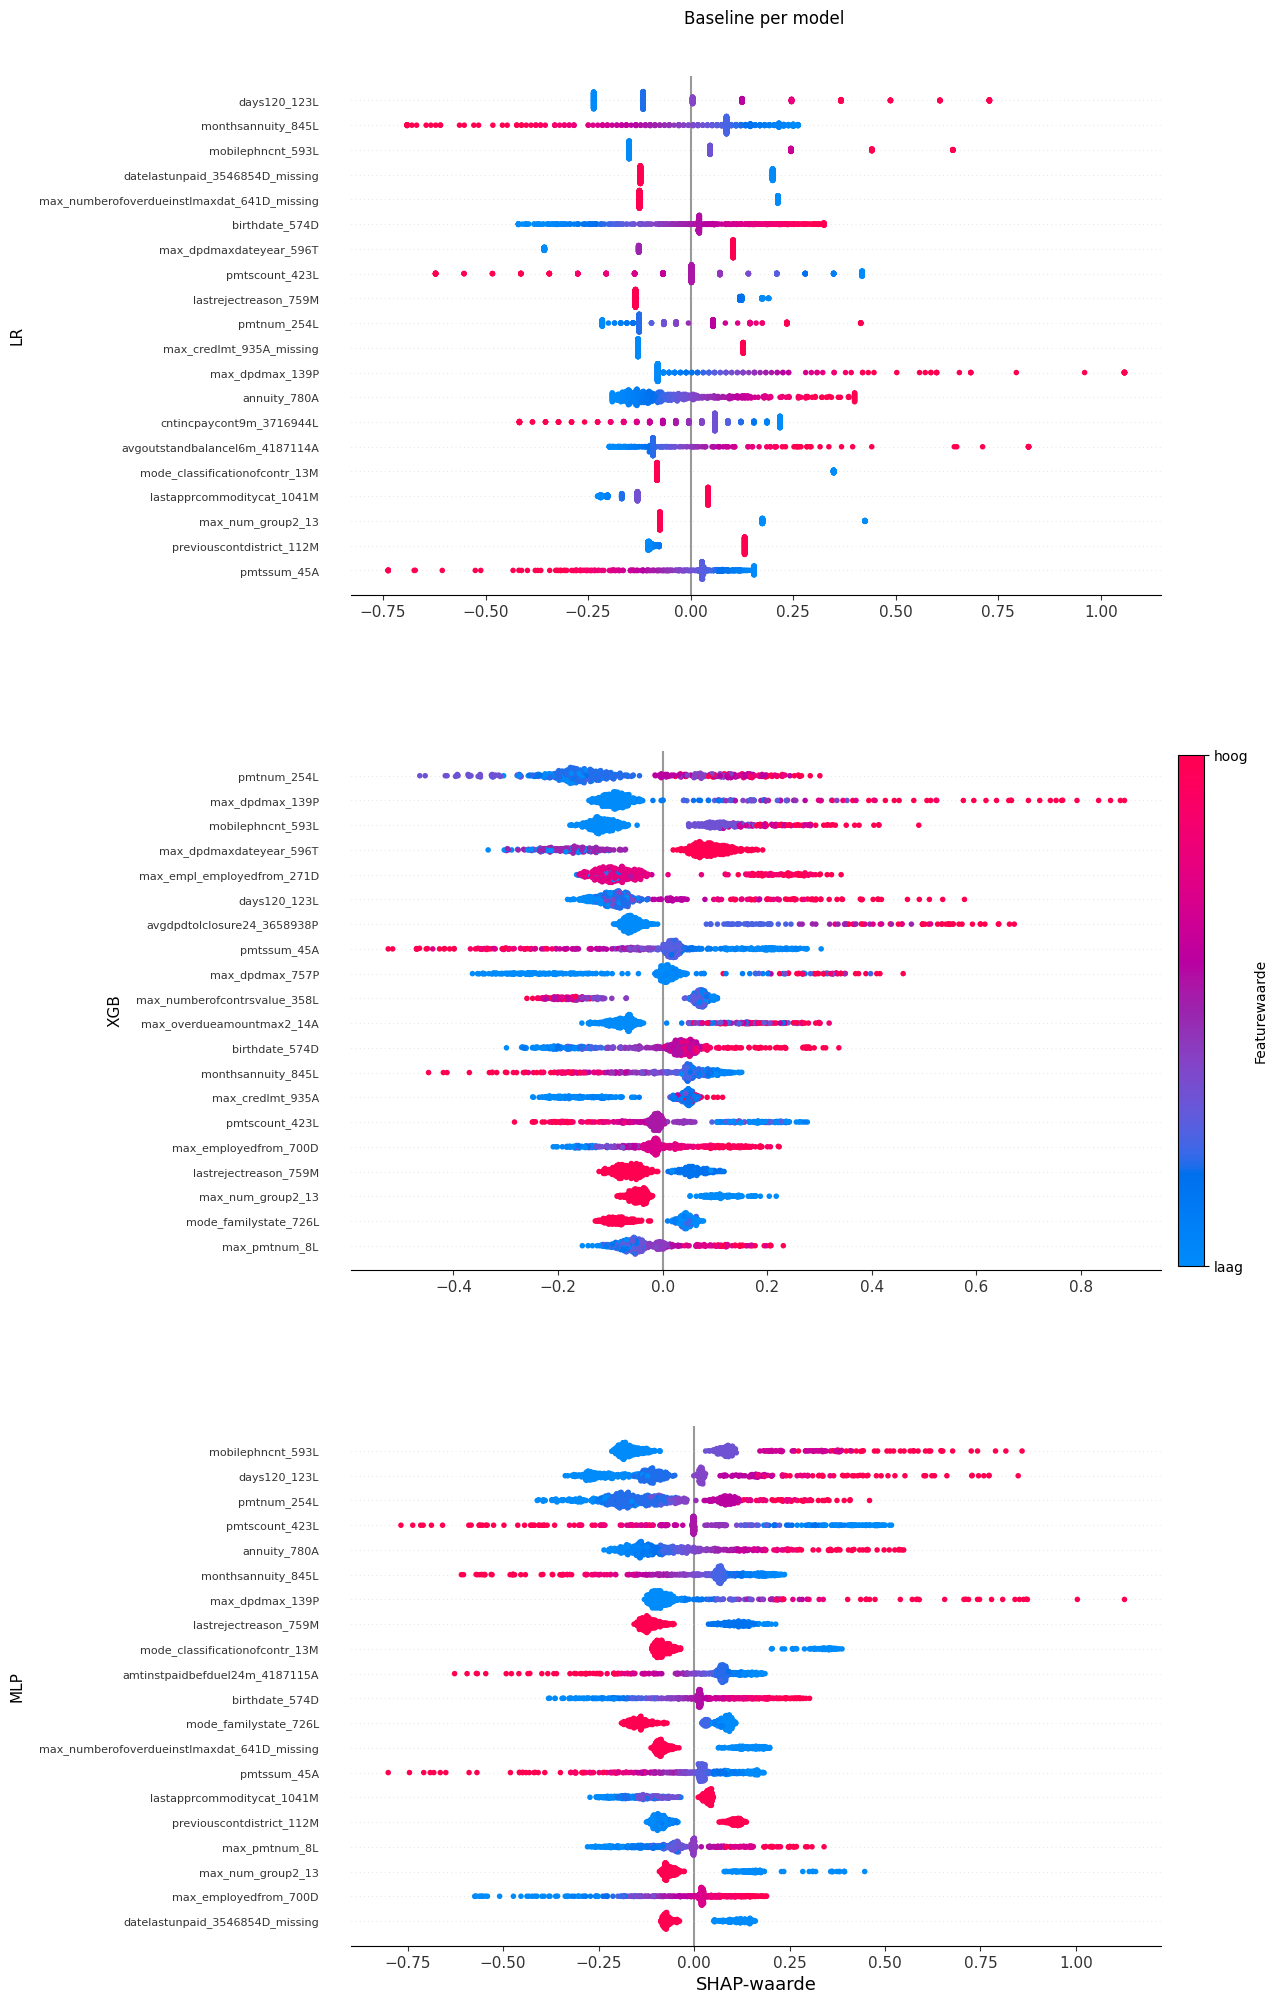

In [34]:
# F11 - Beeswarm van alleen de baseline, de drie modellen onder elkaar in één figuur. Dit is
# het uitgangspunt waar alle weekmetrieken tegen worden afgezet. De volgorde is hier per
# definitie de baselineband, dus rode labels zijn niet nodig: alles op de as zit in de band.
# Geen gedeelde x-as: de drie modellen zitten op een andere absolute SHAP-schaal.
fig, axes = plt.subplots(len(MODELS), 1, figsize=(11, 22))

for ax, model_name in zip(axes, MODELS):
    values = arrays[f"values_{model_name}_{BASELINE_WEEK}"]
    explanation = shap.Explanation(
        values=values,
        data=arrays[f"data_{BASELINE_WEEK}"],
        feature_names=feature_names,
    )

    baseline_order = np.argsort(-np.abs(values).mean(axis=0))

    shap.plots.beeswarm(explanation, max_display=TOP_K, order=baseline_order,
                        color_bar=False, group_remaining_features=False,
                        plot_size=None, ax=ax, show=False)

    for tick in ax.get_yticklabels():
        tick.set_fontsize(8)

    # shap zet zelf een Engelse x-as-label op elk paneel; die halen we hier weg en zetten
    # er achteraf één Nederlandse voor in de plaats, enkel op het onderste paneel.
    ax.set_xlabel("")
    ax.set_ylabel(model_name, fontsize=11, labelpad=10)

axes[-1].set_xlabel("SHAP-waarde")

# Marges eerst vastzetten (kleinere top-marge, zodat de titel niet ver boven het eerste
# paneel blijft hangen), pas daarna suptitle en colorbar toevoegen: die respecteren de
# uiteindelijke aslayout in plaats van hem te verstoren.
fig.subplots_adjust(top=0.96, hspace=0.3)
fig.suptitle("Baseline per model", fontsize=12, y=0.99)

scale = plt.cm.ScalarMappable(cmap=shap.plots.colors.red_blue)
scale.set_array([])
cbar = fig.colorbar(scale, ax=axes, fraction=0.03, pad=0.02, ticks=[0, 1])
cbar.set_ticklabels(["laag", "hoog"])
cbar.set_label("Featurewaarde")

plt.show()

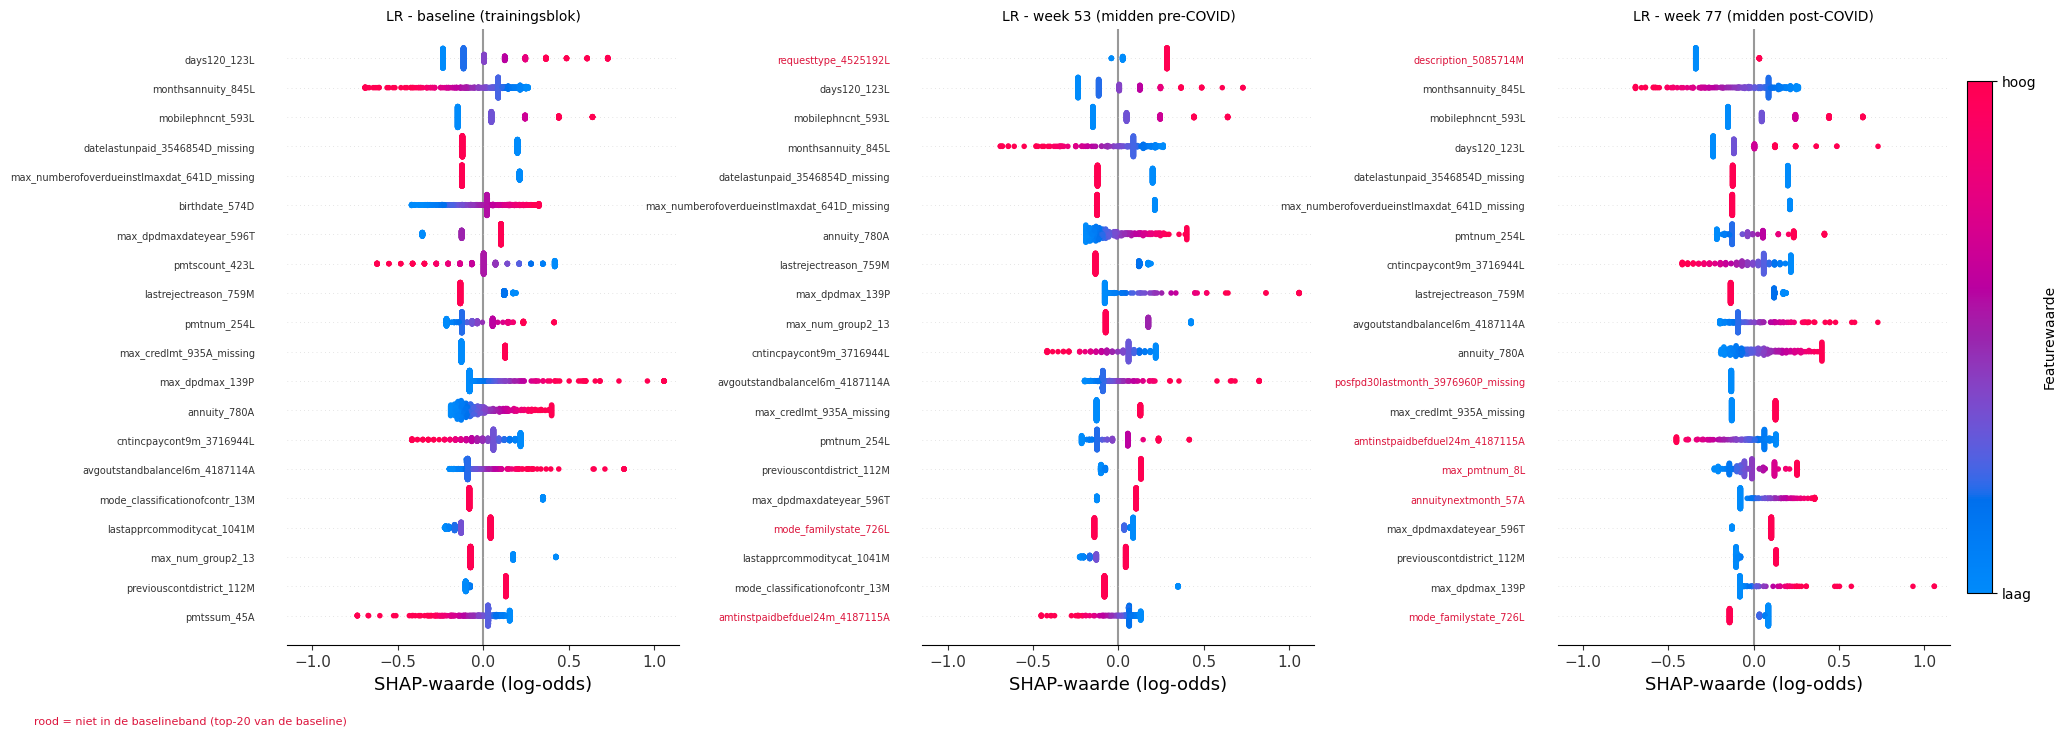

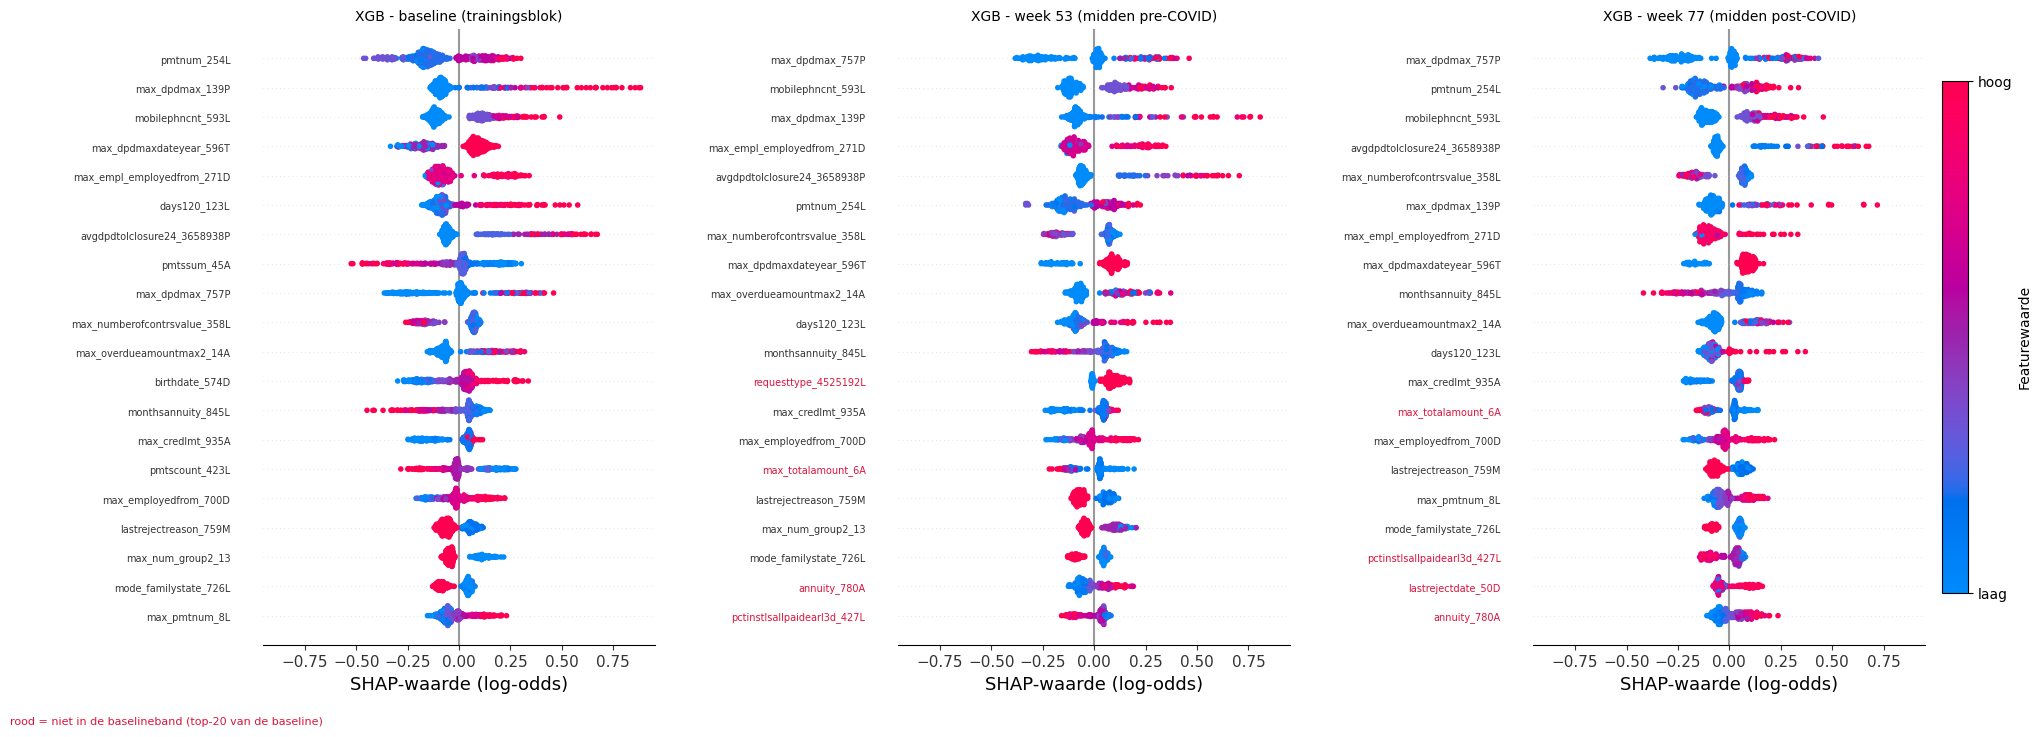

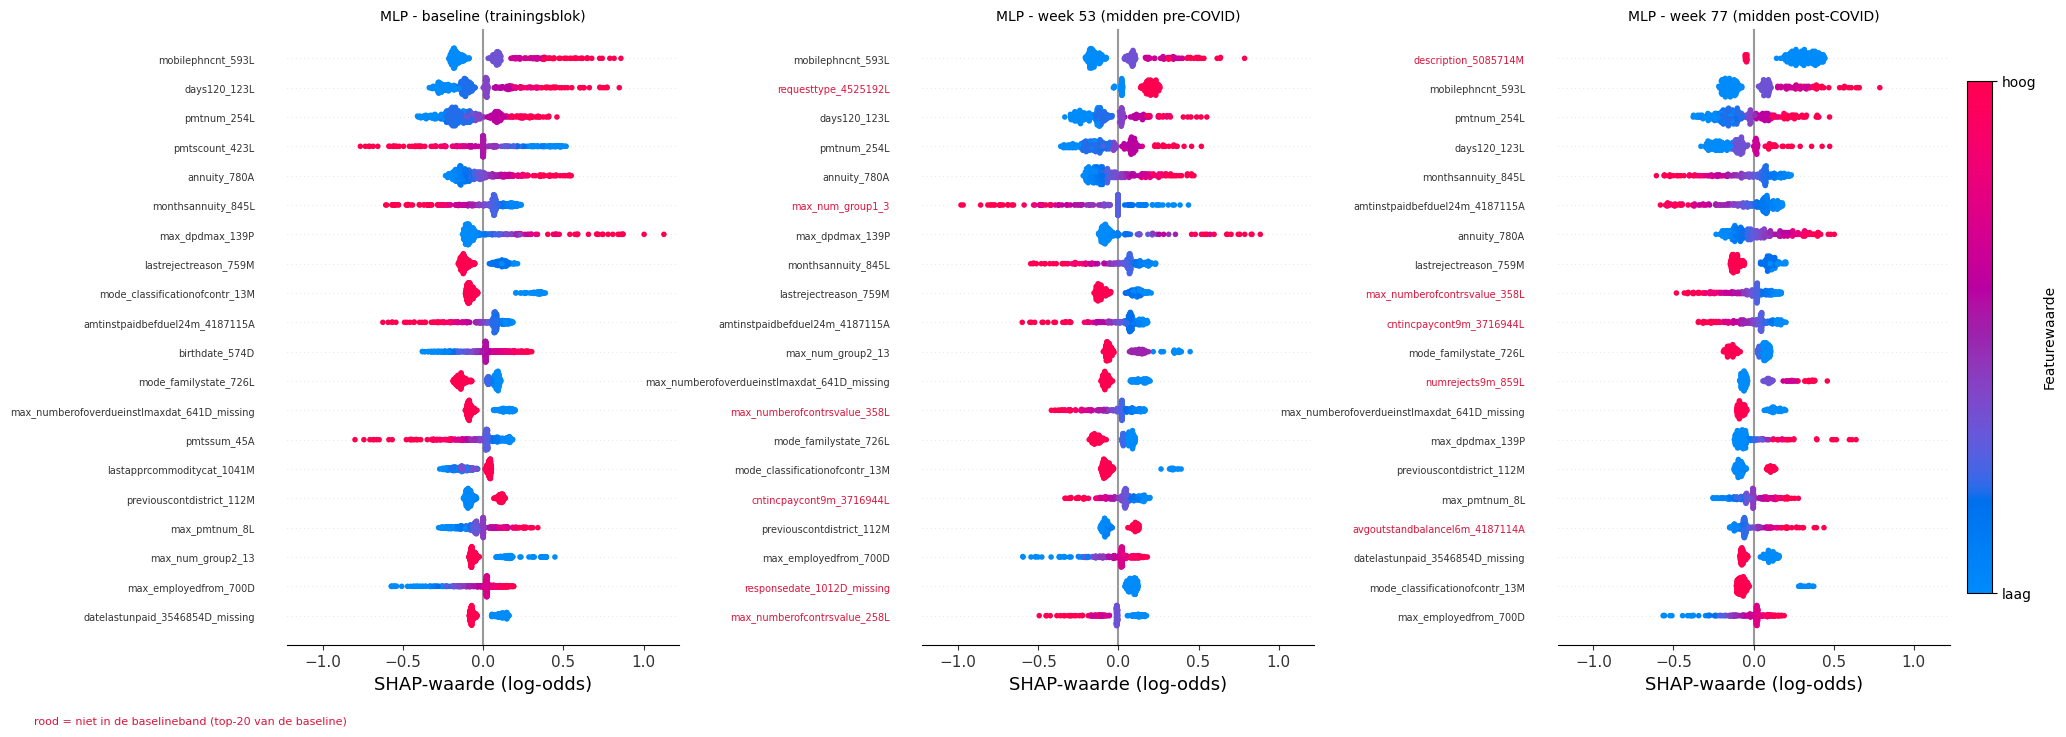

In [35]:
# F10 - Beeswarm per model op de drie momenten uit FOCUS_WEEKS. Elk paneel wordt geordend op
# zijn EIGEN top-TOP_K, dus dezelfde rij is niet dezelfde feature tussen de panelen; de rode
# labels vangen dat op door te markeren wat niet in de baselineband zit.
for model_name in MODELS:
    band_set = set(bands[model_name])

    # wspace ruim: elk paneel draagt nu zijn eigen featurenamen, en die lopen bij de
    # standaardafstand over het paneel ernaast.
    fig, axes = plt.subplots(1, len(FOCUS_WEEKS), figsize=(22, 8),
                             gridspec_kw={"wspace": 0.62})

    for ax, (week, label) in zip(axes, FOCUS_WEEKS.items()):
        values = arrays[f"values_{model_name}_{week}"]
        explanation = shap.Explanation(
            values=values,
            data=arrays[f"data_{week}"],
            feature_names=feature_names,
        )

        week_order = np.argsort(-np.abs(values).mean(axis=0))

        shap.plots.beeswarm(explanation, max_display=TOP_K, order=week_order,
                            color_bar=False, group_remaining_features=False,
                            plot_size=None, ax=ax, show=False)

        # Rood = feature die deze week in de top staat maar niet in de baselineband.
        for tick in ax.get_yticklabels():
            tick.set_fontsize(7)
            if tick.get_text() not in band_set:
                tick.set_color("crimson")

        ax.set_xlabel("SHAP-waarde (log-odds)")
        ax.set_title(f"{model_name} - {label}", fontsize=10)

    limit = max(abs(x) for ax in axes for x in ax.get_xlim())
    for ax in axes:
        ax.set_xlim(-limit, limit)
    for ax in axes[1:]:
        ax.set_xticks(axes[0].get_xticks())
        ax.set_xlim(-limit, limit)

    scale = plt.cm.ScalarMappable(cmap=shap.plots.colors.red_blue)
    scale.set_array([])
    cbar = fig.colorbar(scale, ax=axes, fraction=0.015, pad=0.01, ticks=[0, 1])
    cbar.set_ticklabels(["laag", "hoog"])
    cbar.set_label("Featurewaarde")

    fig.text(0.01, 0.01, f"rood = niet in de baselineband (top-{TOP_K} van de baseline)",
             fontsize=8, color="crimson")

    plt.show()

### Rang (spearman-rank)

In [48]:
# --- Gepaarde Wilcoxon tussen de modellen ---
# Verschillen de modellen onderling in wekelijkse Spearman? Per blok en per modelpaar een
# gepaarde Wilcoxon. De reeksen worden op weeknummer samengevoegd, niet op rijvolgorde,
# zodat een ontbrekende week meteen opvalt in plaats van stil door te schuiven.
MODEL_PAREN = [("LR", "XGB"), ("LR", "MLP"), ("XGB", "MLP")]

wilcoxon_rows = []

for blok_naam, blok_weken in BLOCKS.items():
    for model_a, model_b in MODEL_PAREN:
        reeks_a = weekly[(weekly["model"] == model_a) & (weekly["week"].isin(blok_weken))]
        reeks_b = weekly[(weekly["model"] == model_b) & (weekly["week"].isin(blok_weken))]

        gepaard = pd.merge(reeks_a[["week", "spearman"]], reeks_b[["week", "spearman"]],
                           on="week", suffixes=("_a", "_b"))

        assert len(gepaard) == len(blok_weken), (
            f"{model_a} vs {model_b} in {blok_naam}: {len(gepaard)} gepaarde weken "
            f"in plaats van {len(blok_weken)}")

        verschil = gepaard["spearman_a"] - gepaard["spearman_b"]
        toets = stats.wilcoxon(gepaard["spearman_a"], gepaard["spearman_b"],
                               alternative="two-sided", method="auto")

        wilcoxon_rows.append({
            "blok": blok_naam,
            "model_a": model_a,
            "model_b": model_b,
            "n_weken": len(gepaard),
            "mediaan_verschil": verschil.median(),
            "statistic": toets.statistic,
            "p_waarde": toets.pvalue,
        })

spearman_wilcoxon = pd.DataFrame(wilcoxon_rows)

# Controle op de uitlijning: het blokgemiddelde dat uit deze selectie volgt moet exact
# gelijk zijn aan de spearman_mean die de samenvattingstabel hierboven al berekende. Staat
# voor de tabel, zodat de DataFrame de laatste expressie van de cel blijft en Jupyter ze
# als HTML-tabel toont.
afwijkingen = []
for model_name in MODELS:
    for blok_naam, blok_weken in BLOCKS.items():
        eigen = weekly[(weekly["model"] == model_name)
                       & (weekly["week"].isin(blok_weken))]["spearman"].mean()
        bestaand = summary[(summary["model"] == model_name)
                           & (summary["block"] == blok_naam)]["spearman_mean"].iloc[0]
        afwijkingen.append(abs(eigen - bestaand))

print("Gepaarde Wilcoxon op de wekelijkse Spearman (tweezijdig, geen correctie)")
print(f"Grootste afwijking t.o.v. spearman_mean in de samenvatting: {max(afwijkingen):.2e}")
spearman_wilcoxon.round(4)

Gepaarde Wilcoxon op de wekelijkse Spearman (tweezijdig, geen correctie)
Grootste afwijking t.o.v. spearman_mean in de samenvatting: 0.00e+00


,blok,model_a,model_b,n_weken,mediaan_verschil,statistic,p_waarde
0,volledig,LR,XGB,48,-0.0820,0.0,0.0000
1,volledig,LR,MLP,48,0.0105,550.5,0.7005
2,volledig,XGB,MLP,48,0.0880,0.0,0.0000
3,pre-COVID,LR,XGB,18,-0.1068,0.0,0.0002
4,pre-COVID,LR,MLP,18,-0.0188,37.0,0.0342
5,pre-COVID,XGB,MLP,18,0.0902,0.0,0.0002
6,post-COVID,LR,XGB,30,-0.0744,0.0,0.0000
7,post-COVID,LR,MLP,30,0.0158,102.0,0.0073
8,post-COVID,XGB,MLP,30,0.0880,0.0,0.0000


In [37]:
### --- HAC-trend van de wekelijkse Spearman ---

# Vergelijkbaar met wat we bij predictive stability deden

# Negen regressies (drie modellen x drie blokken). maxlags volgt exact dezelfde regel als
# T3 in r1: consistentie met de predictive stability sectie weegt hier zwaarder dan een
# op maat gekozen bandbreedte.
import statsmodels.api as sm


def newey_west_lag(n):
    """Vuistregel voor de HAC-bandbreedte: 4 * (n/100)^(2/9), minstens 1 week."""
    return max(int(np.floor(4 * (n / 100) ** (2 / 9))), 1)


trend_rows = []

for model_name in MODELS:
    for blok_naam, blok_weken in BLOCKS.items():
        blok = weekly[(weekly["model"] == model_name)
                      & (weekly["week"].isin(blok_weken))].sort_values("week")

        assert len(blok) == len(blok_weken), (
            f"{model_name} in {blok_naam}: {len(blok)} weken "
            f"in plaats van {len(blok_weken)}")

        weken_vanaf_start = blok["week"].to_numpy(dtype=float) - min(blok_weken)
        maxlags = newey_west_lag(len(blok))

        fit = sm.OLS(blok["spearman"].to_numpy(dtype=float),
                     sm.add_constant(weken_vanaf_start)).fit(
            cov_type="HAC", cov_kwds={"maxlags": maxlags}, use_t=True)

        trend_rows.append({
            "model": model_name,
            "blok": blok_naam,
            "n_weken": len(blok),
            "intercept": fit.params[0],
            "helling": fit.params[1],
            "se_helling": fit.bse[1],
            "t_waarde": fit.tvalues[1],
            "p_waarde": fit.pvalues[1],
            "maxlags": maxlags,
        })

spearman_trend = pd.DataFrame(trend_rows)

print("HAC-trend van de wekelijkse Spearman per model en blok (Newey-West)")
print(spearman_trend.round({"intercept": 4, "helling": 5, "se_helling": 5,
                            "t_waarde": 4, "p_waarde": 4}).to_string(index=False))

HAC-trend van de wekelijkse Spearman per model en blok (Newey-West)
model       blok  n_weken  intercept  helling  se_helling  t_waarde  p_waarde  maxlags
   LR   volledig       48     0.5928  0.00012     0.00038    0.3218    0.7491        3
   LR  pre-COVID       18     0.5913  0.00027     0.00155    0.1736    0.8644        2
   LR post-COVID       30     0.5964  0.00004     0.00035    0.1055    0.9167        3
  XGB   volledig       48     0.7213 -0.00149     0.00017   -8.9930    0.0000        3
  XGB  pre-COVID       18     0.7302 -0.00241     0.00047   -5.1595    0.0001        2
  XGB post-COVID       30     0.6877 -0.00107     0.00033   -3.2138    0.0033        3
  MLP   volledig       48     0.6285 -0.00131     0.00041   -3.2382    0.0022        3
  MLP  pre-COVID       18     0.6542 -0.00382     0.00119   -3.2123    0.0054        2
  MLP post-COVID       30     0.5823  0.00006     0.00047    0.1354    0.8932        3


In [38]:
# T-RANG1 - Eén samenvattende tabel voor rang en overlap. Het niveau van beide metrieken
# komt uit `summary`, de helling ernaast is de HAC-trend van de wekelijkse Spearman uit de
# cel hierboven, per week en in dezelfde eenheid als de Spearman zelf. Op de overlap wordt
# bewust geen trend gelegd: die metriek telt features en kan met TOP_K = 20 maar 21 waarden
# aannemen, in stappen van 0,05 - een helling op zo'n grove ladder suggereert een precisie
# die er niet is. De kolomnamen dragen daarom expliciet `spearman_`.
trend_kolommen = (spearman_trend[["model", "blok", "helling", "p_waarde"]]
                  .rename(columns={"blok": "block",
                                   "helling": "spearman_helling_per_week",
                                   "p_waarde": "spearman_helling_p"}))

rang_overlap = summary[["model", "block", "spearman_mean", "spearman_std",
                        "overlap_mean", "overlap_std"]].merge(
    trend_kolommen, on=["model", "block"], how="left", validate="one_to_one")

assert rang_overlap["spearman_helling_per_week"].notna().all(), (
    "niet elk (model, blok) uit summary vond een trendrij")

rang_overlap.to_csv(f"{RESULTS_DIR}/shap_rang_overlap.csv", index=False)

print("Rang en overlap per model en blok "
      "(helling = HAC-trend van de wekelijkse Spearman, per week)")
rang_overlap.round({"spearman_mean": 4, "spearman_std": 4,
                    "overlap_mean": 4, "overlap_std": 4,
                    "spearman_helling_per_week": 5, "spearman_helling_p": 4})

Rang en overlap per model en blok (helling = HAC-trend van de wekelijkse Spearman, per week)


,model,block,spearman_mean,spearman_std,overlap_mean,overlap_std,spearman_helling_per_week,spearman_helling_p
0,LR,volledig,0.5957,0.0287,0.7406,0.0522,0.00012,0.7491
1,LR,pre-COVID,0.5936,0.0389,0.7833,0.0594,0.00027,0.8644
2,LR,post-COVID,0.5969,0.0211,0.7150,0.0233,0.00004,0.9167
3,XGB,volledig,0.6863,0.0262,0.8094,0.0197,-0.00149,0.0000
4,XGB,pre-COVID,0.7098,0.0192,0.8083,0.0192,-0.00241,0.0001
5,XGB,post-COVID,0.6722,0.0186,0.8100,0.0203,-0.00107,0.0033
6,MLP,volledig,0.5977,0.0327,0.6719,0.0573,-0.00131,0.0022
7,MLP,pre-COVID,0.6217,0.0289,0.6500,0.0594,-0.00382,0.0054
8,MLP,post-COVID,0.5833,0.0260,0.6850,0.0528,0.00006,0.8932


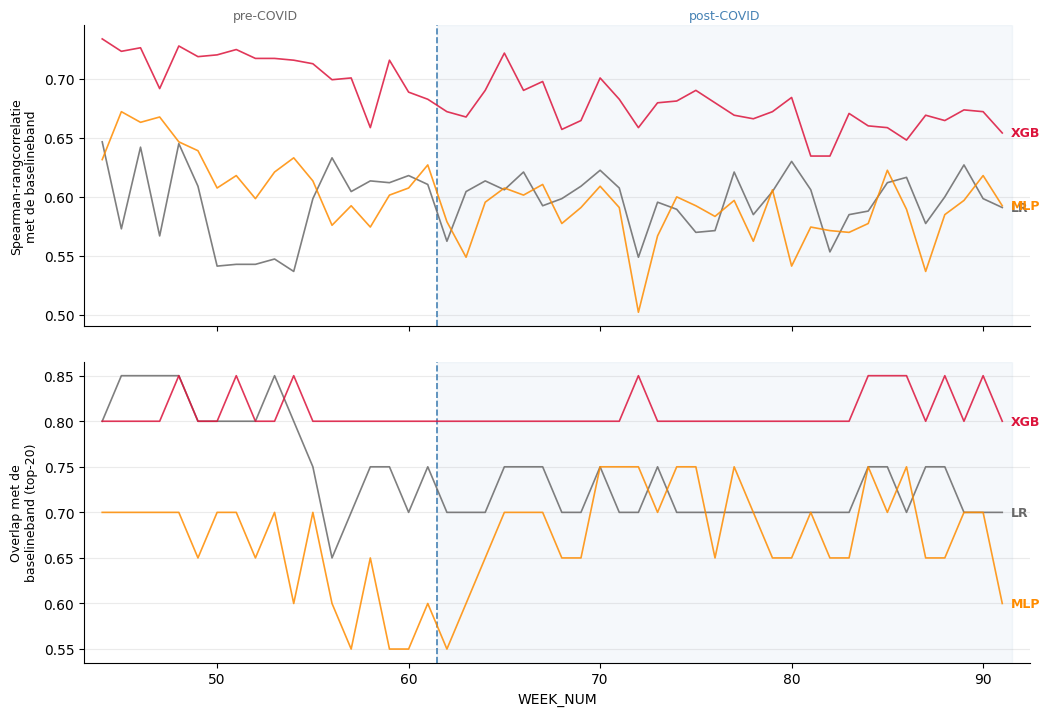

In [39]:
# F4/F6 - Spearman (boven) en overlap (onder) per week, twee panelen op een gedeelde x-as.
#
# Enkel het wekelijkse verloop: de HAC-trend uit de cel hierboven wordt hier niet meer
# overheen gelegd, die staat in de tabel zelf. Voor de overlap zou een trendlijn sowieso
# meer suggereren dan er is - die metriek telt features en kan met TOP_K = 20 maar 21
# waarden aannemen, in stappen van 0,05.
PANELS = [
    ("spearman", "Spearman-rangcorrelatie\nmet de baselineband"),
    ("overlap", f"Overlap met de\nbaselineband (top-{TOP_K})"),
]

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True,
                         gridspec_kw={"hspace": 0.12})
fig.subplots_adjust(left=0.09, right=0.95, top=0.93, bottom=0.08)

for ax, (column, ylabel) in zip(axes, PANELS):
    # Het post-COVID blok krijgt een lichte achtergrond in plaats van alleen een streepje:
    # zo is meteen zichtbaar dat het twee aparte regimes zijn.
    ax.axvspan(COVID_WEEK - 0.5, max(TEST_WEEKS) + 0.5,
               color="steelblue", alpha=0.05, zorder=0)
    ax.axvline(COVID_WEEK - 0.5, color="steelblue", linestyle="--",
               linewidth=1.2, zorder=1)

    for model_name in MODELS:
        model_weekly = weekly[weekly["model"] == model_name].sort_values("week")
        ax.plot(model_weekly["week"], model_weekly[column], linewidth=1.2, alpha=0.85,
                color=COLORS[model_name], zorder=2)

    # Direct label rechts op de laatste weekwaarde: de modellen zijn zo ook zonder kleur
    # te onderscheiden.
    eind_week = max(TEST_WEEKS)
    for model_name in MODELS:
        model_weekly = weekly[weekly["model"] == model_name]
        y_eind = model_weekly[model_weekly["week"] == eind_week][column].iloc[0]

        ax.annotate(model_name, xy=(eind_week, y_eind), xytext=(6, 0),
                    textcoords="offset points", va="center", fontsize=9,
                    color=COLORS[model_name], fontweight="bold")

    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.02)

for blok_naam, kleur in [("pre-COVID", "dimgray"), ("post-COVID", "steelblue")]:
    axes[0].text(np.mean(BLOCKS[blok_naam]), 1.02, blok_naam,
                 transform=axes[0].get_xaxis_transform(), ha="center",
                 fontsize=9, color=kleur)

axes[-1].set_xlabel("WEEK_NUM")

plt.show()

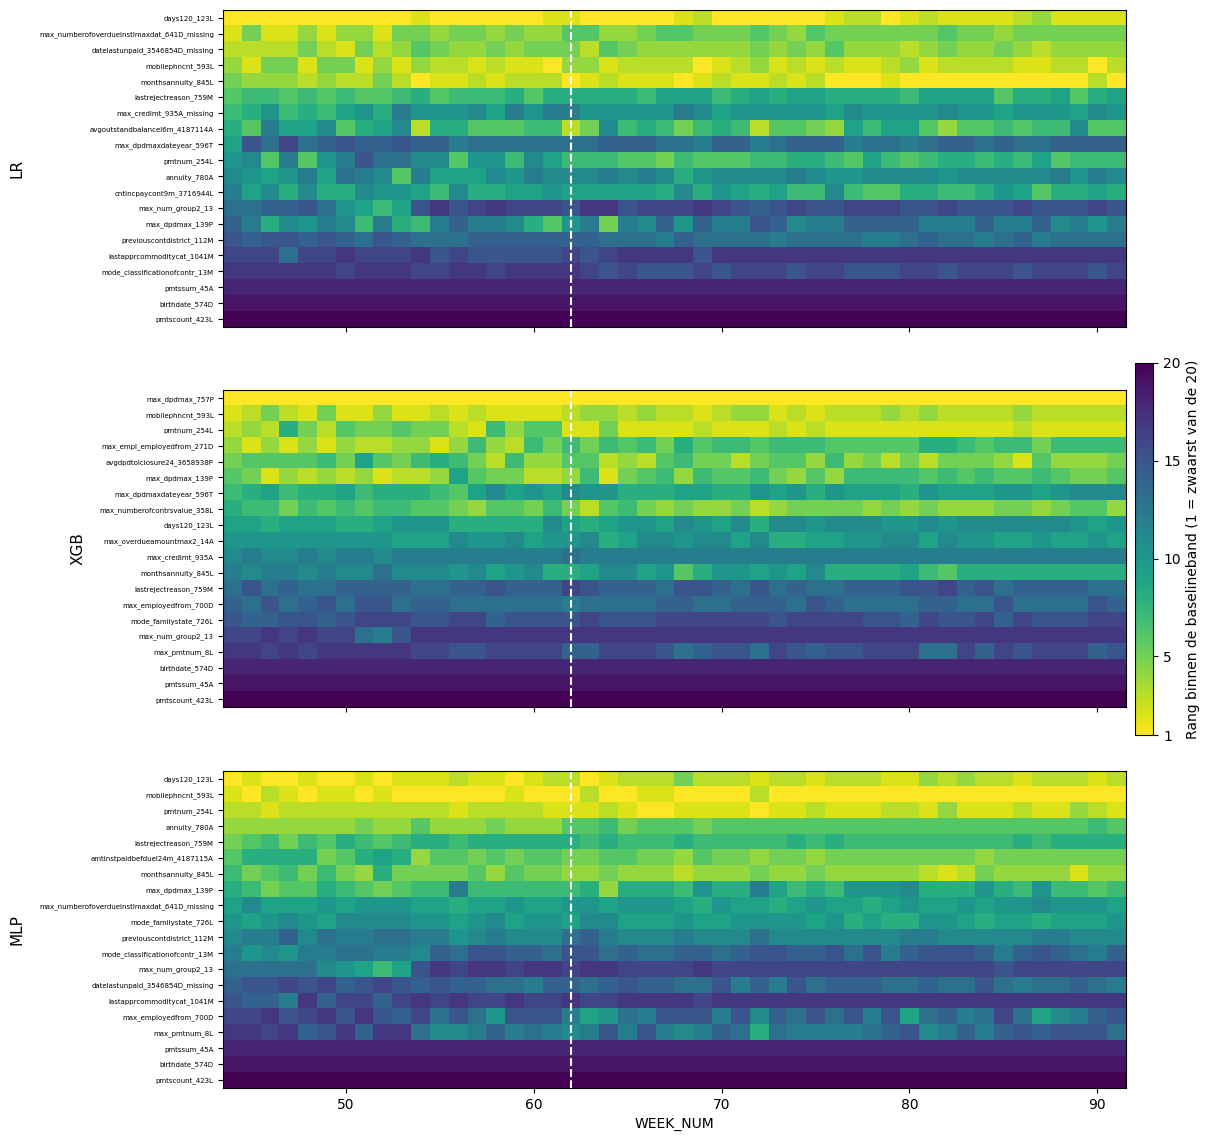

In [40]:
# F8 - Rangdrift van de baselineband, per model. De rang wordt BINNEN de band gemeten, dus
# elke week is een permutatie van 1..TOP_K en er valt niets af te kappen. De rijen staan op
# volgorde van de eerste testweek: die kolom is daardoor een zuiver verloop van licht naar
# donker, en alles wat daarna van kleur verschiet is echte verschuiving. Dit is dezelfde
# grootheid als de Spearman in F4, maar per feature uitgesplitst in plaats van samengevat
# in een getal per week.
FIRST_WEEK = min(TEST_WEEKS)

fig, axes = plt.subplots(len(MODELS), 1, figsize=(12, 14), sharex=True)

for ax, model_name in zip(axes, MODELS):
    band_table = tables[model_name].loc[list(TEST_WEEKS), bands[model_name]]
    band_ranks = band_table.rank(axis=1, ascending=False)

    order = band_ranks.loc[FIRST_WEEK].sort_values().index

    im = ax.imshow(band_ranks[order].to_numpy().T, aspect="auto", cmap="viridis_r",
                   vmin=1, vmax=TOP_K,
                   extent=[min(TEST_WEEKS) - 0.5, max(TEST_WEEKS) + 0.5,
                           TOP_K - 0.5, -0.5])
    ax.axvline(COVID_WEEK, color="white", linestyle="--", linewidth=1.5)

    ax.set_yticks(range(TOP_K))
    ax.set_yticklabels(order, fontsize=5)
    ax.set_ylabel(model_name, fontsize=11, labelpad=10)

axes[-1].set_xlabel("WEEK_NUM")

cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01,
                    ticks=[1] + list(range(5, TOP_K + 1, 5)))
cbar.set_label(f"Rang binnen de baselineband (1 = zwaarst van de {TOP_K})")

plt.show()

### Waarden (CoV)

(zie ook tabel eerder voor waardes ivm cov)

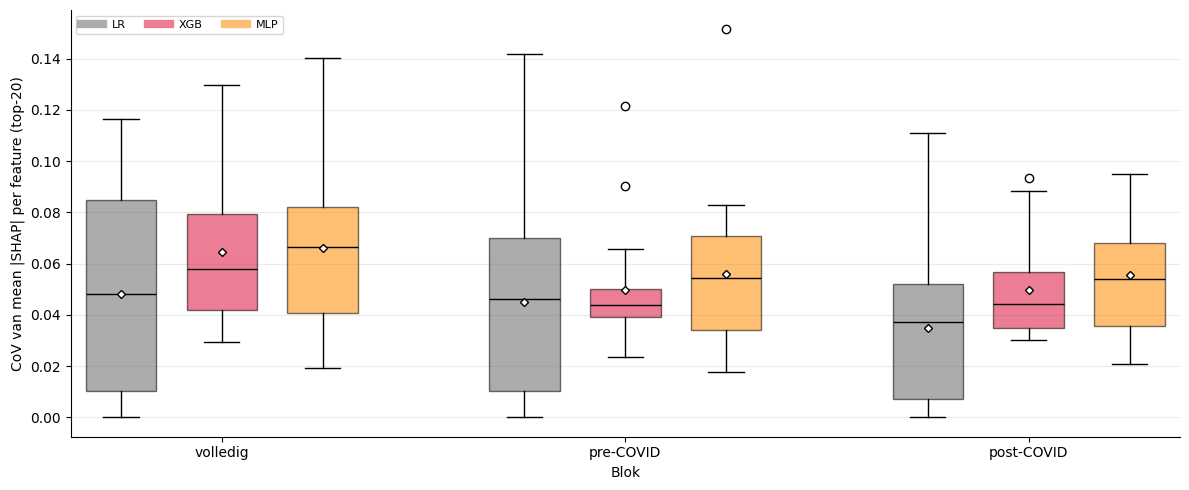

In [41]:
# F7 - Verdeling van de CoV-waarden per feature in de baselineband, per model en per blok.
# De cov_mean uit de samenvattingstabel is het gemiddelde van elke box.
fig, ax = plt.subplots(figsize=(12, 5))

box_data = []
box_positions = []
box_colors = []
tick_positions = []

for block_index, block_name in enumerate(BLOCKS):
    group_start = block_index * (len(MODELS) + 1)
    for model_index, model_name in enumerate(MODELS):
        box_data.append(cov_per_feature[(model_name, block_name)])
        box_positions.append(group_start + model_index)
        box_colors.append(COLORS[model_name])
    tick_positions.append(group_start + (len(MODELS) - 1) / 2)

boxes = ax.boxplot(
    box_data, positions=box_positions, widths=0.7, patch_artist=True,
    showmeans=True,
    meanprops=dict(marker="D", markerfacecolor="white",
                   markeredgecolor="black", markersize=4),
)
for patch, color in zip(boxes["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
for median in boxes["medians"]:
    median.set_color("black")

ax.set_xticks(tick_positions)
ax.set_xticklabels(list(BLOCKS))
ax.set_xlabel("Blok")
ax.set_ylabel(f"CoV van mean |SHAP| per feature (top-{TOP_K})")

legend_handles = [plt.Line2D([], [], color=COLORS[m], linewidth=6, alpha=0.55, label=m)
                  for m in MODELS]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8, ncol=3)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

In [ ]:
# T-CoV1 - Gepaarde moving-block bootstrap op cov_mean.
#
# Zelfde opzet als T4 in r1 3.2.3: blokken van L aaneengesloten weken worden met teruglegging
# aan elkaar geplakt tot een reeks van n weken, met L = newey_west_lag(n), dezelfde regel als
# de HAC-bandbreedte. De weekindices worden EEN keer per iteratie getrokken en aan de drie
# modellen voorgelegd, zodat aandeel_laagste een gepaarde rangtelling is. De tabel staat op de
# ruwe mean |SHAP|; cov_std is de spreiding van de bootstrapverdeling (de standaardfout).
B_COV = 5000


def moving_block_idx(n, L, rng):
    """Moving-block indices: aaneengesloten stukken van L weken tot er n weken staan."""
    starts = rng.integers(0, n - L + 1, size=int(np.ceil(n / L)))
    return np.concatenate([np.arange(s, s + L) for s in starts])[:n]


def band_matrix(model_name, blok_weken):
    """Weken x TOP_K matrix van de ruwe mean |SHAP| van de eigen baselineband."""
    return tables[model_name].loc[blok_weken, bands[model_name]].to_numpy(dtype=float)


def cov_mean_van(M):
    """CoV per feature (ddof=1, zoals cov_per_feature) en dan gemiddeld over de TOP_K.
    Werkt ook op een (B, weken, TOP_K) stapel: de weekas is altijd de voorlaatste."""
    return (M.std(axis=-2, ddof=1) / M.mean(axis=-2)).mean(axis=-1)


boot_rows = []
boot_draws = []
L_per_blok = {}

for blok_naam, blok_weken in BLOCKS.items():
    n = len(blok_weken)
    L = newey_west_lag(n)
    L_per_blok[blok_naam] = L

    rng = np.random.default_rng(SEED)
    idx_all = np.stack([moving_block_idx(n, L, rng) for _ in range(B_COV)])

    punt = np.empty(len(MODELS))
    boots = np.empty((B_COV, len(MODELS)))

    for j, model_name in enumerate(MODELS):
        M = band_matrix(model_name, blok_weken)
        punt[j] = cov_mean_van(M)
        boots[:, j] = cov_mean_van(M[idx_all])

    laagste = np.asarray(MODELS)[boots.argmin(axis=1)]

    for j, model_name in enumerate(MODELS):
        boot_rows.append({
            "model": model_name,
            "blok": blok_naam,
            "n_weken": n,
            "cov_mean": punt[j],
            "cov_std": boots[:, j].std(ddof=1),
            "ci_laag": np.percentile(boots[:, j], 2.5),
            "ci_hoog": np.percentile(boots[:, j], 97.5),
            "aandeel_laagste": (laagste == model_name).mean(),
        })
        boot_draws.append(pd.DataFrame({
            "blok": blok_naam, "model": model_name,
            "iteratie": np.arange(B_COV), "cov_mean": boots[:, j]}))

cov_bootstrap = pd.DataFrame(boot_rows)
cov_bootstrap_draws = pd.concat(boot_draws, ignore_index=True)

# Controle: de puntschatting op de ruwe waarden is per definitie de cov_mean die de
# samenvattingstabel al berekende.
controle = cov_bootstrap.merge(
    summary[["model", "block", "cov_mean"]],
    left_on=["model", "blok"], right_on=["model", "block"], suffixes=("", "_summary"))
afwijking = (controle["cov_mean"] - controle["cov_mean_summary"]).abs().max()

print(f"T-CoV1  Gepaarde moving-block bootstrap op cov_mean (B = {B_COV}, seed {SEED}, "
      f"CoV met ddof=1, ruwe mean |SHAP|)")
print("        blokgrootte L per blok: "
      + ", ".join(f"{b} L={L} ({len(BLOCKS[b]) - L + 1} blokken)" for b, L in L_per_blok.items()))
print(f"        grootste afwijking t.o.v. cov_mean in de samenvattingstabel: {afwijking:.1e}")
cov_bootstrap.round(4)

In [49]:
# T-CoV2 - Beschrijvende spreiding van de TOP_K feature-CoV's per model en blok, op de ruwe
# mean |SHAP|. Geen bootstrap: dit zijn de twintig waarden waarvan cov_mean het gemiddelde is.
spreiding_rows = []
per_feature_rows = []

for blok_naam, blok_weken in BLOCKS.items():
    for model_name in MODELS:
        M = band_matrix(model_name, blok_weken)
        covs = pd.Series(M.std(axis=0, ddof=1) / M.mean(axis=0), index=bands[model_name])

        q25, mediaan, q75 = covs.quantile([0.25, 0.5, 0.75])
        spreiding_rows.append({
            "blok": blok_naam,
            "model": model_name,
            "mediaan": mediaan,
            "q25": q25,
            "q75": q75,
            "iqr": q75 - q25,
            "hoogste_cov": covs.max(),
            "feature_hoogste_cov": covs.idxmax(),
        })

        per_feature_rows.append(
            covs.rename("cov").rename_axis("feature").reset_index().assign(
                blok=blok_naam, model=model_name))

cov_spreiding = pd.DataFrame(spreiding_rows)
cov_per_feature_lang = pd.concat(per_feature_rows, ignore_index=True)[
    ["blok", "model", "feature", "cov"]]

print(f"T-CoV2  Spreiding van de {TOP_K} feature-CoV's (ruwe mean |SHAP|, geen bootstrap)")
cov_spreiding.round(4)

T-CoV2  Spreiding van de 20 feature-CoV's (ruwe mean |SHAP|, geen bootstrap)


,blok,model,mediaan,q25,q75,iqr,hoogste_cov,feature_hoogste_cov
0,volledig,LR,0.0482,0.0104,0.0850,0.0746,0.1162,max_num_group2_13
1,volledig,XGB,0.0580,0.0420,0.0792,0.0371,0.1299,pmtscount_423L
2,volledig,MLP,0.0665,0.0406,0.0819,0.0413,0.1402,max_num_group2_13
3,pre-COVID,LR,0.0463,0.0105,0.0698,0.0594,0.1419,max_num_group2_13
4,pre-COVID,XGB,0.0437,0.0393,0.0501,0.0108,0.1213,max_num_group2_13
5,pre-COVID,MLP,0.0544,0.0340,0.0709,0.0370,0.1514,max_num_group2_13
6,post-COVID,LR,0.0372,0.0070,0.0520,0.0449,0.1108,max_dpdmax_139P
7,post-COVID,XGB,0.0443,0.0349,0.0567,0.0218,0.0934,avgdpdtolclosure24_3658938P
8,post-COVID,MLP,0.0541,0.0356,0.0681,0.0325,0.0951,max_dpdmax_139P


In [44]:
# T-CoV3 - Doorsnede van de drie baselinebands. Eenmalige telling: de bands staan vast op
# week -1 en hebben dus geen blokdimensie.
from itertools import combinations

band_sets = {model_name: set(bands[model_name]) for model_name in MODELS}

overlap_rows = [{"vergelijking": f"{model_a} & {model_b}",
                 "doorsnede": len(band_sets[model_a] & band_sets[model_b])}
                for model_a, model_b in combinations(MODELS, 2)]
overlap_rows.append({"vergelijking": " & ".join(MODELS),
                     "doorsnede": len(set.intersection(*band_sets.values()))})

band_overlap = pd.DataFrame(overlap_rows)

print(f"T-CoV3  Doorsnede van de drie baseline top-{TOP_K} bands")
band_overlap

T-CoV3  Doorsnede van de drie baseline top-20 bands
  vergelijking  doorsnede
      LR & XGB         11
      LR & MLP         16
     XGB & MLP         13
LR & XGB & MLP         10
